In [1]:
import importlib
import matplotlib.pyplot as plt
import pandas as pd
import sys

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')
sys.path.insert(0, '../../../..')
sys.path.insert(0, '../../../../..')

# Decoding
import suffix_pred.evalaution.decode_test_set_suffixes
importlib.reload(suffix_pred.evalaution.decode_test_set_suffixes)
from suffix_pred.evalaution.decode_test_set_suffixes import TestSetSuffixDecoder, DecodingConfig

# Evaluation metrics
import suffix_pred.evalaution.evalaution_metrics
importlib.reload(suffix_pred.evalaution.evalaution_metrics)
from suffix_pred.evalaution.evalaution_metrics import (evaluate_dls, dls_per_prefix_length, average_dls, load_decoded_suffixes)

# Model
import suffix_pred.models.K_UED_LSTM
importlib.reload(suffix_pred.models.K_UED_LSTM)
from suffix_pred.models.K_UED_LSTM import DropoutUncertaintyEncoderDecoderLSTM

In [2]:
# Model
file_path_model = '../../../../../../models/Helpdesk/decision/Helpdesk_UED_LSTM_v1_DA.pkl'
model = DropoutUncertaintyEncoderDecoderLSTM.load(file_path_model, dropout=0.1)

# Load the data
# Path to your pickle file (saved with torch.save)
file_path_test = '../../../../../../data/Helpdesk/tensor_data/normal/helpdesk_all_5_test.pkl'
# Load the dataset using torch.load
test_dataset = torch.load(file_path_test, weights_only=False)

Dynamic data set categories:  ([('Activity', 15, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'EOS': 4, 'INVALID': 5, 'Insert ticket': 6, 'RESOLVED': 7, 'Require upgrade': 8, 'Resolve SW anomaly': 9, 'Resolve ticket': 10, 'Schedule intervention': 11, 'Take in charge ticket': 12, 'VERIFIED': 13, 'Wait': 14}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Data set static categories:  ([('VariantIndex', 175, {'1': 1, '10': 2, '100': 3, '101': 4, '102': 5, '103': 6, '104': 7, '105': 8, '106': 9, '109': 10, '11': 11, '110': 12, '111': 13, '118': 1

In [3]:
# Step 1: Decode suffixes (probabilistic)
config = DecodingConfig(concept_name="Activity",
                        eos_value="EOS",
                        probabilistic_samples=100,
                        num_processes=32)

decoder = TestSetSuffixDecoder(model=model, dataset=test_dataset, config=config)

mode = "probabilistic"
outputs = decoder.decode(mode=mode,
                         random_order=False,
                         cache_path="../../../../../../eval_results/Helpdesk/decision_train/helpdesk_ued_lstm_decision_train_outputs_fixed_tf.pkl",
                         reuse_cache=False,
                         parallel_inference=True,
                         num_processes=32)

print(f"Decoded {len(outputs)} prefix rows in '{mode}' mode")

# --- Step 2: Evaluate DLS from decoded outputs ---
prob_df = evaluate_dls(outputs, probabilistic_reduction="mean")
prob_per_prefix = dls_per_prefix_length(prob_df)

prob_avg = average_dls(prob_df)
prob_min = float(prob_df["dls_min"].mean())
prob_max = float(prob_df["dls_max"].mean())

print(f"Average DLS ({mode}, mean over T samples): {prob_avg:.4f}")
print(f"Average DLS min ({mode}): {prob_min:.4f}")
print(f"Average DLS max ({mode}): {prob_max:.4f}")

Probabilistic inference chunks:   0%|          | 0/32 [00:00<?, ?it/s]

Decoded 3343 prefix rows in 'probabilistic' mode
Average DLS (probabilistic, mean over T samples): 0.8285
Average DLS min (probabilistic): 0.1816
Average DLS max (probabilistic): 0.9780


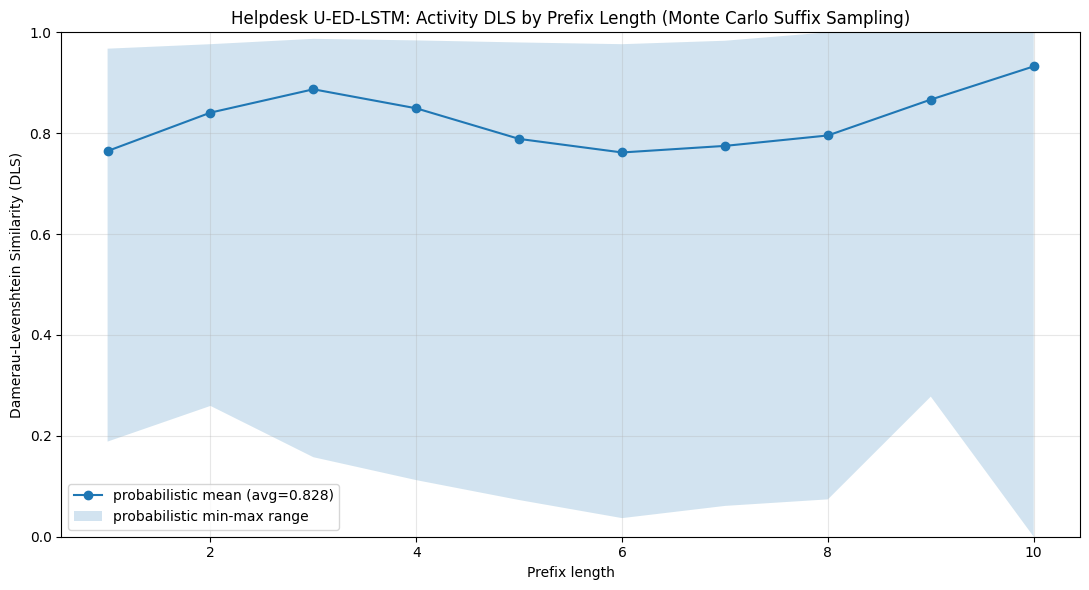

,mode,average_dls,average_dls_min,average_dls_max
0,probabilistic,0.828494,0.181635,0.978001


In [4]:
# One combined plot (single method requested: probabilistic only)
plt.figure(figsize=(11, 6))

plt.plot(prob_per_prefix["prefix_len"],
         prob_per_prefix["dls"],
         marker="o",
         label=f"probabilistic mean (avg={prob_avg:.3f})")

# Plot min/max range band for probabilistic decoding if available
if {"dls_min", "dls_max"}.issubset(prob_per_prefix.columns):
    plt.fill_between(prob_per_prefix["prefix_len"],
                     prob_per_prefix["dls_min"],
                     prob_per_prefix["dls_max"],
                     alpha=0.2,
                     label="probabilistic min-max range")

plt.title("Helpdesk U-ED-LSTM: Activity DLS by Prefix Length (Monte Carlo Suffix Sampling)")
plt.xlabel("Prefix length")
plt.ylabel("Damerau-Levenshtein Similarity (DLS)")
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Optional summary table
summary = pd.DataFrame({
    "mode": [mode],
    "average_dls": [prob_avg],
    "average_dls_min": [prob_min],
    "average_dls_max": [prob_max],
}).sort_values("average_dls", ascending=False).reset_index(drop=True)
summary

In [5]:
# Load decoded outputs from pickle and inspect 5 example prefixes
cached_outputs = load_decoded_suffixes("../../../../../../eval_results/Helpdesk/decision_train/helpdesk_ued_lstm_decision_train_outputs_fixed_tf.pkl")

for row in cached_outputs[:5]:
    print(f"Case: {row['case_id']}  |  Prefix len: {row['prefix_len']}")
    print(f"  Prefix:         {row['prefix']}")
    print(f"  Target suffix:  {row['target_suffix']}")
    print(f"  Sampled suffixes ({len(row['decoded_suffixes'])}):")
    for i, s in enumerate(row["decoded_suffixes"][:5]):
        print(f"    [{i}] {s}")
    if len(row["decoded_suffixes"]) > 5:
        print(f"    ... and {len(row['decoded_suffixes']) - 5} more")
    print()

Case: Case 944  |  Prefix len: 1
  Prefix:         ['Assign seriousness']
  Target suffix:  ['Take in charge ticket', 'Take in charge ticket', 'Take in charge ticket', 'Wait', 'Wait', 'Take in charge ticket', 'Resolve ticket', 'Closed']
  Sampled suffixes (100):
    [0] ['Take in charge ticket', 'Assign seriousness', 'Take in charge ticket', 'Wait', 'Resolve ticket', 'Closed']
    [1] ['Take in charge ticket', 'Resolve SW anomaly', 'Schedule intervention', 'Take in charge ticket', 'Take in charge ticket', 'Take in charge ticket', 'Resolve ticket', 'Closed']
    [2] ['Take in charge ticket', 'Take in charge ticket', 'Take in charge ticket', 'Resolve SW anomaly', 'Take in charge ticket', 'Resolve ticket', 'Closed']
    [3] ['Resolve ticket', 'Take in charge ticket', 'Wait', 'Wait', 'Take in charge ticket', 'Resolve ticket', 'Closed']
    [4] ['Take in charge ticket', 'Resolve ticket', 'Wait', 'Resolve ticket', 'Resolve ticket', 'Resolve ticket']
    ... and 95 more

Case: Case 944  |  Pr